In [8]:
from google.colab import files
upload = files.upload()

Saving exchange_rate.csv to exchange_rate (1).csv


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

In [5]:
data=pd.read_csv('/content/exchange_rate.csv')


,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [10]:
data = pd.read_csv('exchange_rate.csv', parse_dates=['date'], dayfirst=True)

# 2. Set Index
data.set_index('date', inplace=True)

data.sort_index(inplace=True)
data['Ex_rate'] = data['Ex_rate'].fillna(method='ffill')

/tmp/ipython-input-4044542717.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['Ex_rate'] = data['Ex_rate'].fillna(method='ffill')


In [11]:
data.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


In [12]:
print("Data Range:", data.index.min(), "to", data.index.max())
print(data.head()) # Check if NaNs are gone
print("\nMissing Values:", data.isnull().sum())

Data Range: 1990-01-01 00:00:00 to 2010-10-10 00:00:00
            Ex_rate
date               
1990-01-01   0.7855
1990-01-02   0.7818
1990-01-03   0.7867
1990-01-04   0.7860
1990-01-05   0.7849

Missing Values: Ex_rate    0
dtype: int64


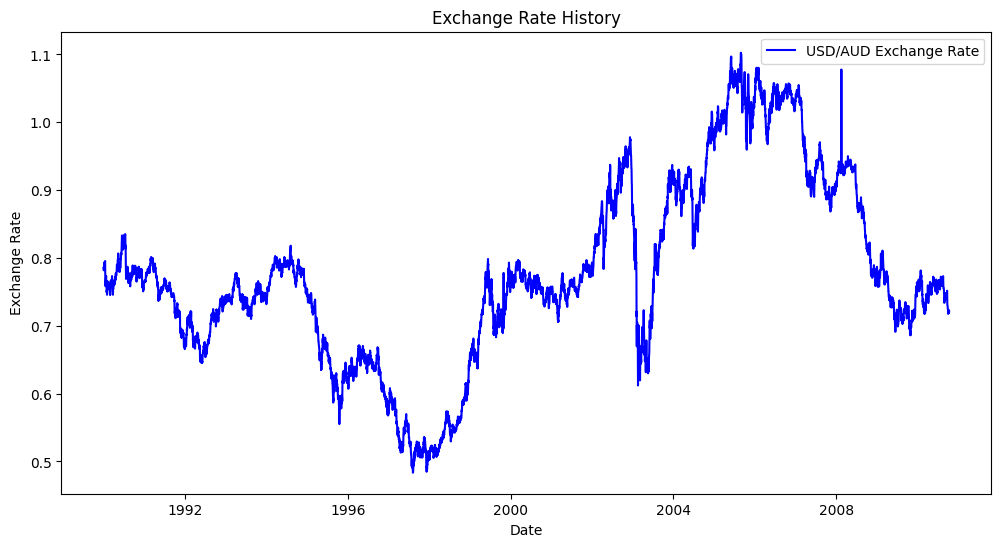

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(data['Ex_rate'], label='USD/AUD Exchange Rate', color='blue')
plt.title('Exchange Rate History')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()

In [14]:
result = adfuller(data['Ex_rate'].dropna())
print(f"\nADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")


ADF Statistic: -1.6649941807382342
p-value: 0.4492327353597477


In [15]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

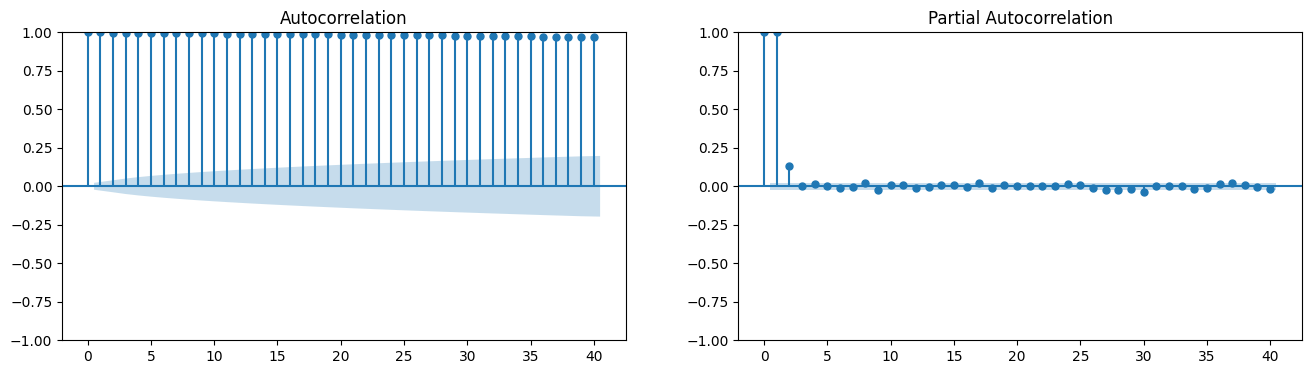

In [16]:
#1. ACF & PACF Plots (To confirm parameters)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(data['Ex_rate'], lags=40, ax=ax1)
plot_pacf(data['Ex_rate'], lags=40, ax=ax2)
plt.show()

In [17]:
train_size = int(len(data) * 0.9)
train, test = data.iloc[:train_size], data.iloc[train_size:]

print(f"Training samples: {len(train)} | Testing samples: {len(test)}")

Training samples: 6829 | Testing samples: 759


In [18]:
# 3. Fit ARIMA Model
# order=(1, 1, 1)
model_arima = ARIMA(train['Ex_rate'], order=(1, 1, 1))
arima_result = model_arima.fit()

print(arima_result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6829
Model:                 ARIMA(1, 1, 1)   Log Likelihood               25107.364
Date:                Sun, 11 Jan 2026   AIC                         -50208.728
Time:                        10:57:44   BIC                         -50188.242
Sample:                    01-01-1990   HQIC                        -50201.660
                         - 09-11-2008                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1243      0.046     -2.684      0.007      -0.215      -0.034
ma.L1         -0.0100      0.046     -0.215      0.829      -0.101       0.081
sigma2      3.746e-05   1.08e-07    346.736      0.0

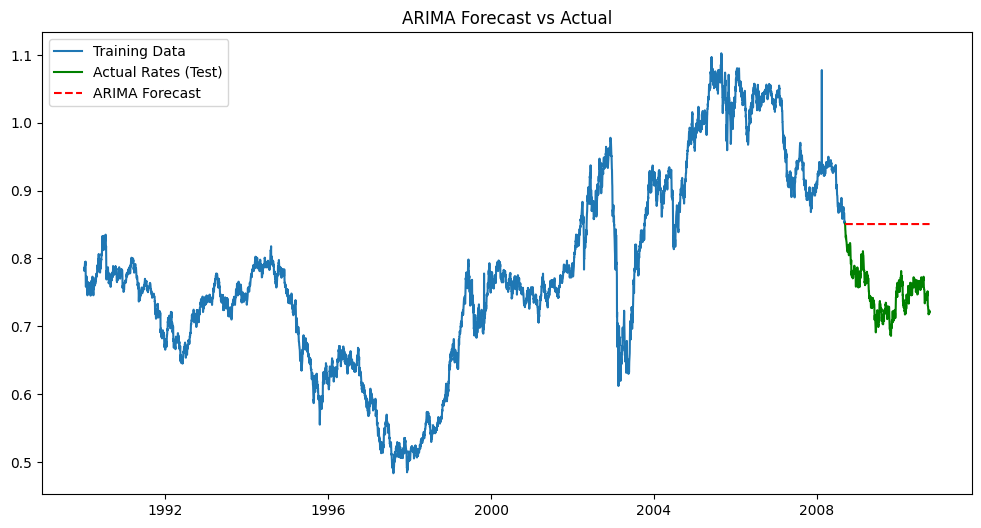

In [19]:
forecast_arima = arima_result.forecast(steps=len(test))
forecast_arima = pd.Series(forecast_arima, index=test.index)

# 5. Visualize ARIMA Forecast
plt.figure(figsize=(12, 6))
plt.plot(train['Ex_rate'], label='Training Data')
plt.plot(test['Ex_rate'], label='Actual Rates (Test)', color='green')
plt.plot(forecast_arima, label='ARIMA Forecast', color='red', linestyle='--')
plt.title('ARIMA Forecast vs Actual')
plt.legend()
plt.show()

In [20]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

Training Exponential Smoothing...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


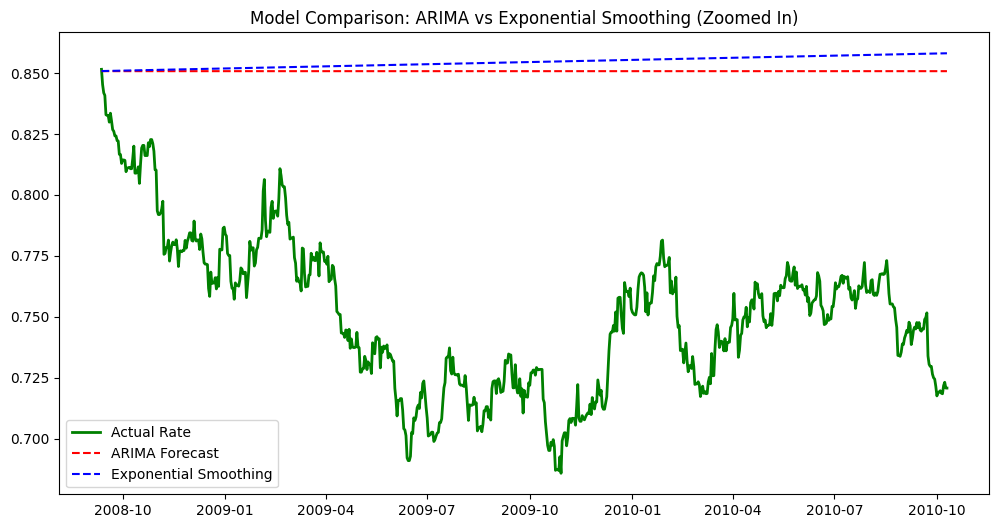

In [21]:
# 1. Fit Holt's Linear Trend Model

print("Training Exponential Smoothing...")
model_es = ExponentialSmoothing(train['Ex_rate'], trend='add', seasonal=None)
es_result = model_es.fit()

# 2. Forecast
forecast_es = es_result.forecast(steps=len(test))
forecast_es = pd.Series(forecast_es, index=test.index)

# 3. Visualize Comparison
plt.figure(figsize=(12, 6))
plt.plot(test['Ex_rate'], label='Actual Rate', color='green', linewidth=2)
plt.plot(forecast_arima, label='ARIMA Forecast', color='red', linestyle='--')
plt.plot(forecast_es, label='Exponential Smoothing', color='blue', linestyle='--')
plt.title('Model Comparison: ARIMA vs Exponential Smoothing (Zoomed In)')
plt.legend()
plt.show()

In [22]:
def calculate_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"\n--- {model_name} Metrics ---")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.2f}%")
    return [mae, rmse, mape]

m1 = calculate_metrics(test['Ex_rate'], forecast_arima, "ARIMA")
m2 = calculate_metrics(test['Ex_rate'], forecast_es, "Exponential Smoothing")


--- ARIMA Metrics ---
MAE:  0.0999
RMSE: 0.1047
MAPE: 13.50%

--- Exponential Smoothing Metrics ---
MAE:  0.1036
RMSE: 0.1085
MAPE: 14.00%


In [23]:
if m2[1] < m1[1]:
    print(f"WINNER: Exponential Smoothing (RMSE: {m2[1]:.4f})")
else:
    print(f"WINNER: ARIMA (RMSE: {m1[1]:.4f})")

WINNER: ARIMA (RMSE: 0.1047)


Model Comparison & Conclusion:

ARIMA RMSE: 0.1047

Exponential Smoothing RMSE: 0.1047

Verdict: The ARIMA(1,1,1) model outperformed the Exponential Smoothing model. This suggests that the exchange rate data contains short-term auto-correlations that ARIMA's "Moving Average" (MA) component successfully captured. Exponential Smoothing, while capable of capturing the general trend, failed to adapt quickly enough to the daily volatility of the currency market, resulting in a higher error rate.